In [ ]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, BaseLineDataLoaderManager, GraphDataLoaderManager
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel, SimpleGCNModel, GCNLSTMModel
from src.evaluation import Evaluator

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 12
lag_num         = 4

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    # quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    feature_popsize     = True,
    feature_kreise_classes= True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )



In [2]:
baselinedata = BaseLineDataLoaderManager(epidata_orchestrator)

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]
# baseline_models = [persistence]

baseline_evaluation = Evaluator(baseline_models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:04<00:00, 269.08it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


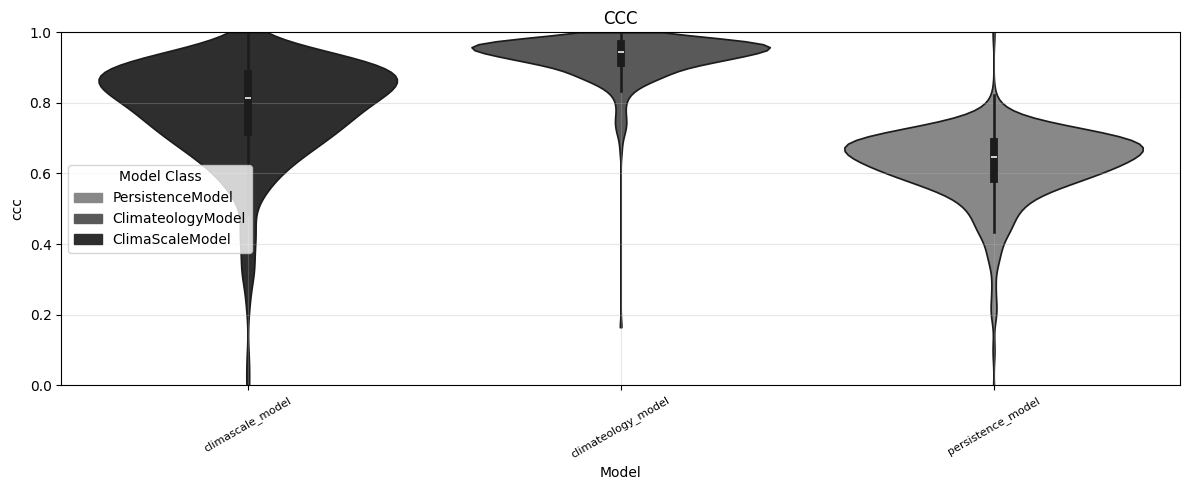

In [3]:
baseline_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'violin',vmin = 0, vmax = 1).show()

In [4]:
graphloader1 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test3').build()
graphloader2 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test1').build()
graphloader3 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test2').build()
graphloader4 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()


In [5]:
node = 26
seq = 0

x = []

for data in graphloader1.dataloader_main:    
    x.append(data.x[node,-1, seq])

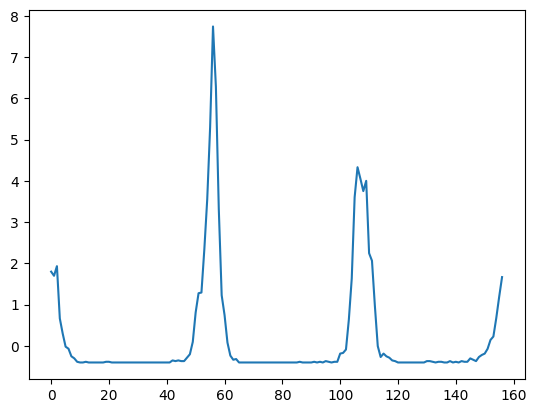

In [6]:
import matplotlib.pyplot as plt
plt.plot(x)

In [7]:
from src.models import GCN2Model, DecoupledGCNModel


==                   spatial1                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 12), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.3726   |   0.6507   |    v     |           |
|  002  |   1.0939   |   0.4886   |    v     |           |
|  003  |   0.9327   |   0.3901   |    v     |           |
|  004  |   0.8181   |   0.3275   |    v     |           |
|  005  |   0.7416   |   0.2860   |    v     |           |
|  006  |   0.6872   |   0.2579   |    v     |           |
|  007  |   0.6410   |   0.2373   |    v     |           |
|  008  |   0.5944   |   0.2225   |    v     |           |
|  009  |   0.5566   |   0.2105   |    v     |           |
|  010  |   0.5277   |   0.2026   |    v     |           |
|  011  |   0.5036   |   0.1957   |    v     |           |
|  012  |   0.4717   |   0.1909   |    

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  100  |   0.2707   |   0.1509   |          |   5/15    |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 434.28it/s]

Test loss: 0.2112
forecasted ✓


DecoupledGCNModel(name='spatial1')

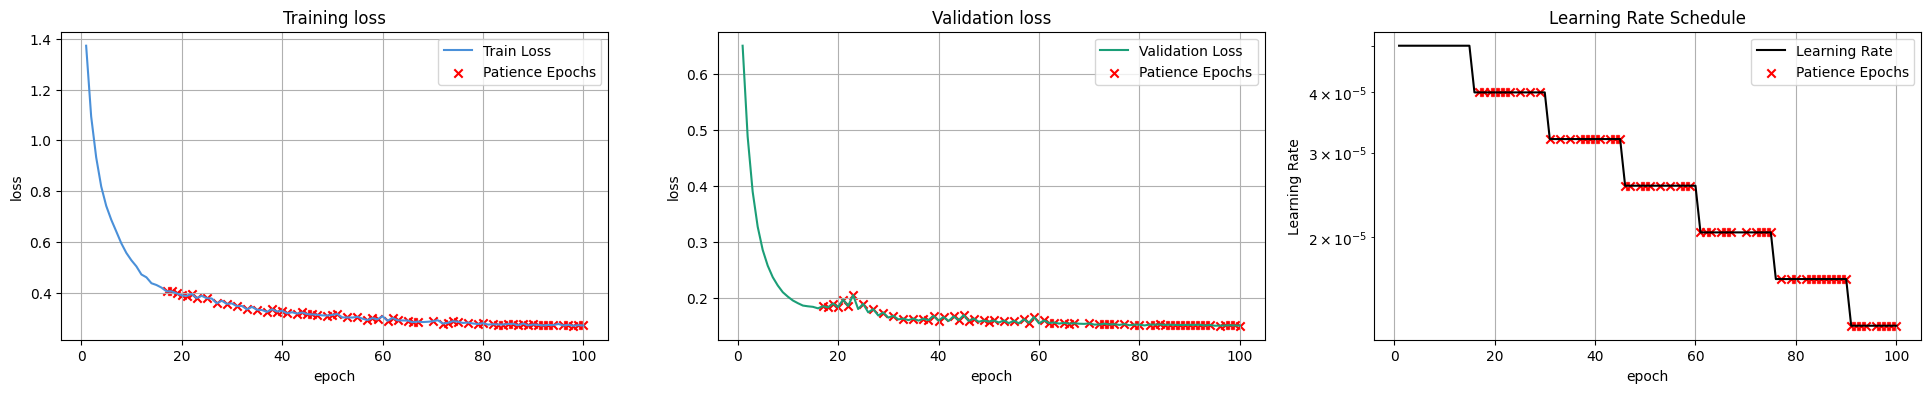

In [8]:
global_hparams = {
    'lr': 0.00005,
    'n_epochs' : 100
}

model1 = DecoupledGCNModel(graphloader1, name = 'spatial1', verbose = 2)
model1.set_model_hparams()
model1.set_global_hparams(**global_hparams)
model1.train()
model1.forecast()

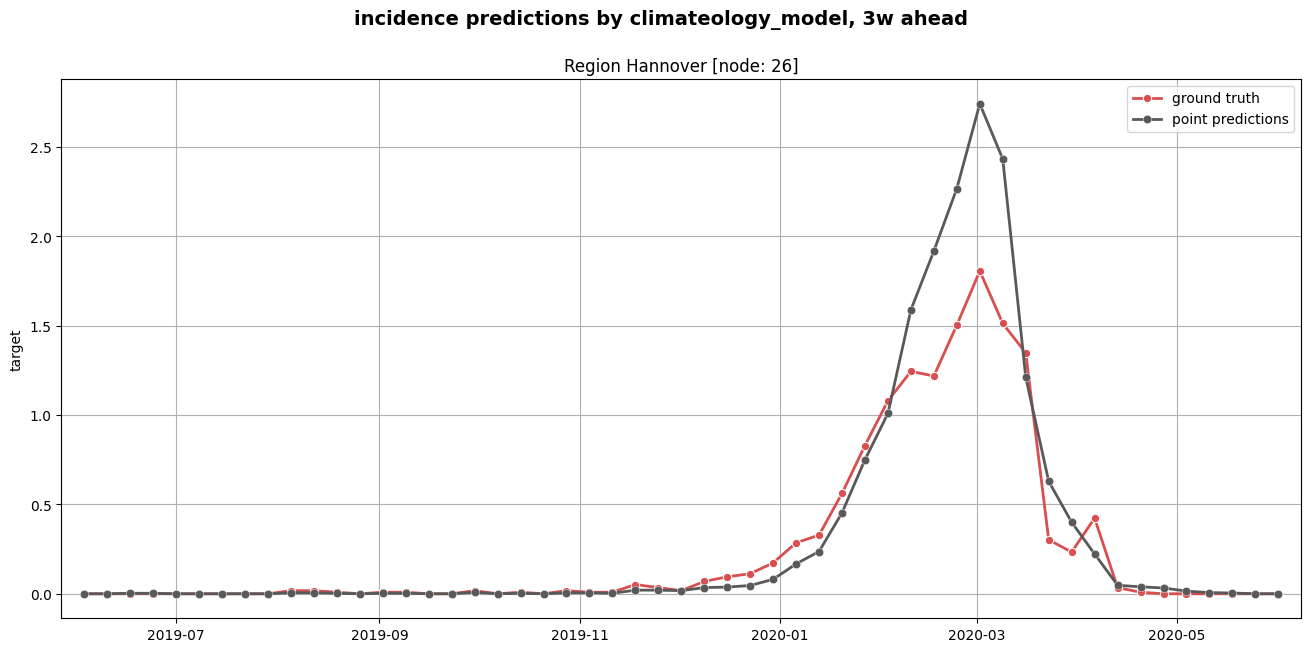

In [9]:
climateology.show_forecasts(26).show()


==                   spatial2                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 12), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.4203   |   0.7331   |    v     |           |
|  002  |   1.1344   |   0.5990   |    v     |           |
|  003  |   1.0142   |   0.5017   |    v     |           |
|  004  |   0.9048   |   0.4261   |    v     |           |
|  005  |   0.8314   |   0.3671   |    v     |           |
|  006  |   0.7547   |   0.3236   |    v     |           |
|  007  |   0.6970   |   0.2887   |    v     |           |
|  008  |   0.6408   |   0.2615   |    v     |           |
|  009  |   0.5945   |   0.2372   |    v     |           |
|  010  |   0.5600   |   0.2201   |    v     |           |
|  011  |   0.5338   |   0.2039   |    v     |           |
|  012  |   0.4978   |   0.1946   |  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  100  |   0.2577   |   0.1527   |          |   6/15    |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 242.55it/s]

Test loss: 0.2001
forecasted ✓


DecoupledGCNModel(name='spatial2')

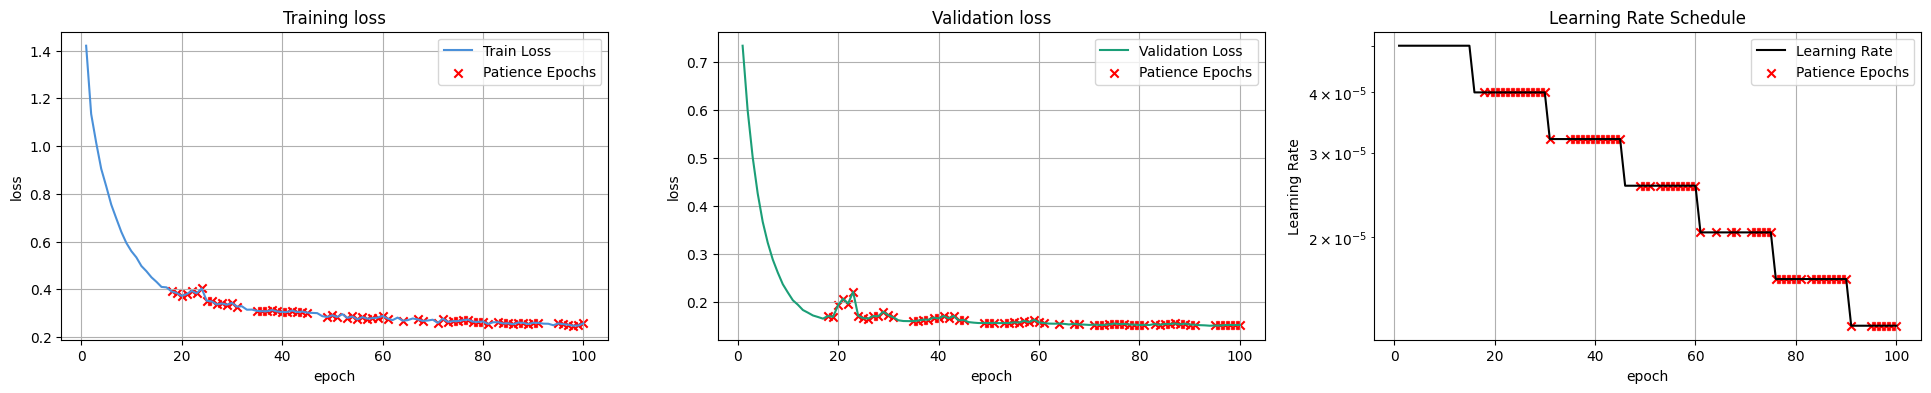

In [10]:
model2 = DecoupledGCNModel(graphloader2, name = 'spatial2', verbose = 2)
model2.set_model_hparams()
model2.set_global_hparams(**global_hparams)
model2.train()
model2.forecast()


==                   spatial3                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 12), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.2216   |   0.6235   |    v     |           |
|  002  |   1.0222   |   0.4818   |    v     |           |
|  003  |   0.8650   |   0.3921   |    v     |           |
|  004  |   0.7543   |   0.3173   |    v     |           |
|  005  |   0.6624   |   0.2667   |    v     |           |
|  006  |   0.5917   |   0.2342   |    v     |           |
|  007  |   0.5505   |   0.2138   |    v     |           |
|  008  |   0.5141   |   0.1982   |    v     |           |
|  009  |   0.4888   |   0.1969   |    v     |           |
|  010  |   0.4636   |   0.1826   |    v     |           |
|  011  |   0.4489   |   0.1870   |          |   1/15    |
|  012  |   0.4363   |   0.1746   |  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.1578
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 240.99it/s]


Test loss: 0.2044
forecasted ✓


DecoupledGCNModel(name='spatial3')

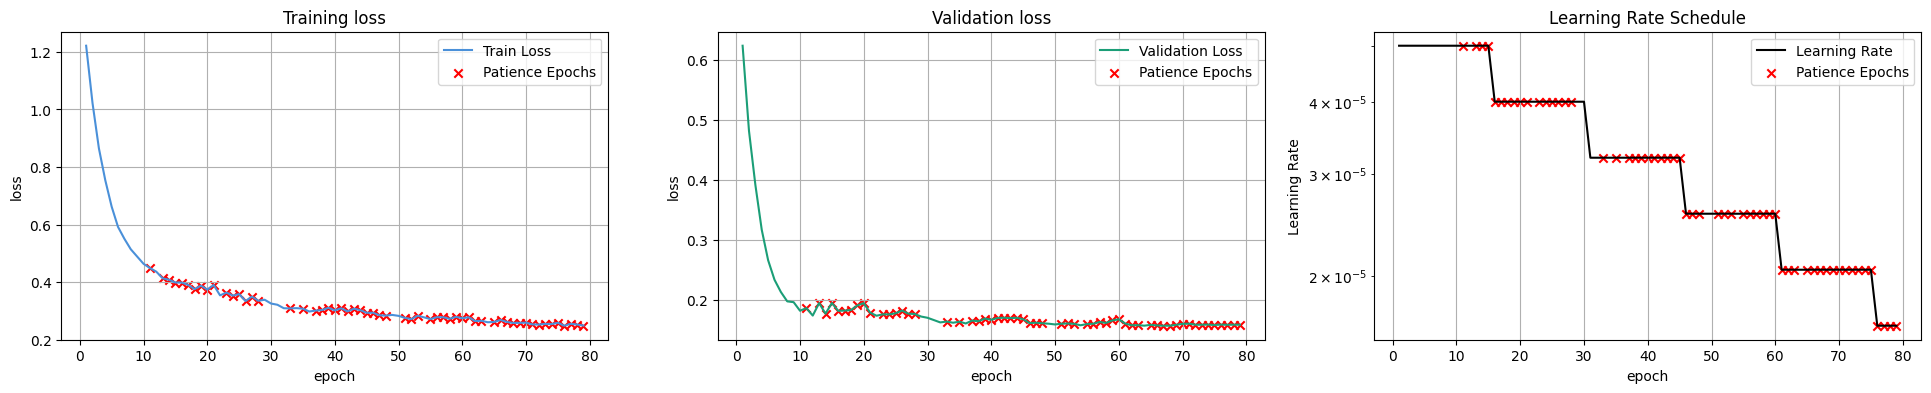

In [11]:
model3 = DecoupledGCNModel(graphloader3, name = 'spatial3', verbose = 2)
model3.set_model_hparams()
model3.set_global_hparams(**global_hparams)
model3.train()
model3.forecast()


==                   spatial4                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 12), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.3899   |   0.6843   |    v     |           |
|  002  |   1.1254   |   0.5108   |    v     |           |
|  003  |   0.9501   |   0.4247   |    v     |           |
|  004  |   0.8476   |   0.3666   |    v     |           |
|  005  |   0.7719   |   0.3246   |    v     |           |
|  006  |   0.7123   |   0.2906   |    v     |           |
|  007  |   0.6652   |   0.2647   |    v     |           |
|  008  |   0.6231   |   0.2465   |    v     |           |
|  009  |   0.5815   |   0.2279   |    v     |           |
|  010  |   0.5547   |   0.2199   |    v     |           |
|  011  |   0.5311   |   0.2036   |    v     |           |
|  012  |   0.5119   |   0.2131   |  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  100  |   0.2633   |   0.1589   |    v     |           |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 424.73it/s]

Test loss: 0.1959
forecasted ✓


DecoupledGCNModel(name='spatial4')

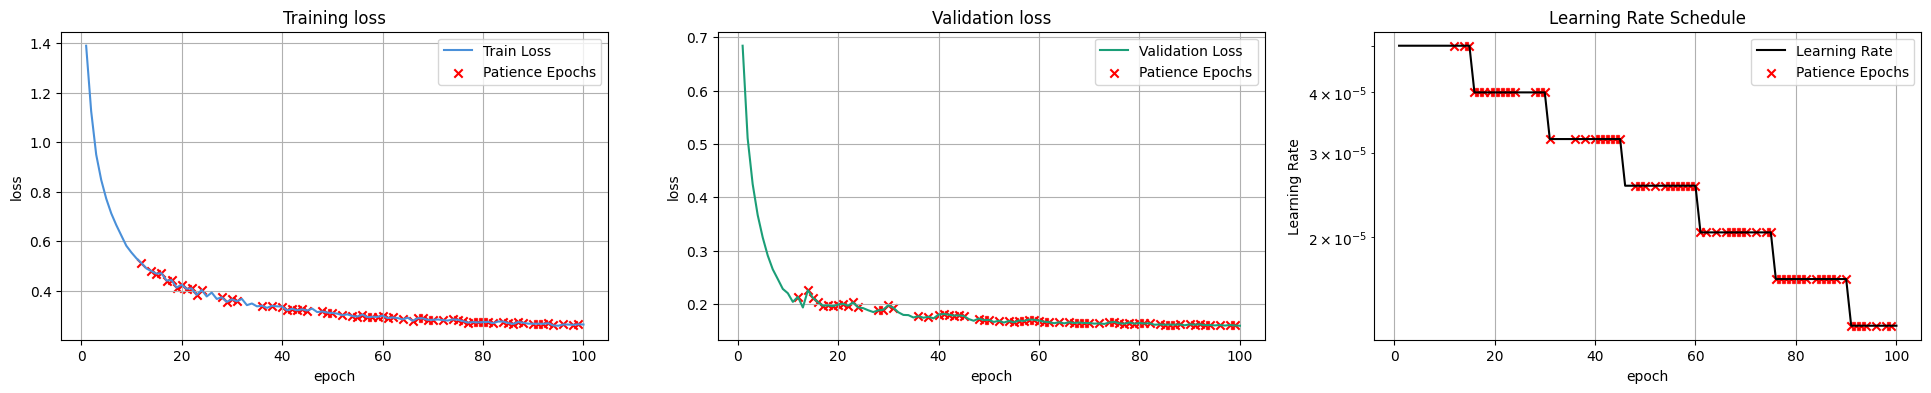

In [12]:
model4 = DecoupledGCNModel(graphloader4, name = 'spatial4', verbose = 2)
model4.set_model_hparams()
model4.set_global_hparams(**global_hparams)
model4.train()
model4.forecast()

In [24]:
# models = [model1, model2, model3, model4]
models  = [model1, model2, model3, model4]

model_evaluation = Evaluator(baseline_models + models).add_evaluation()

  0%|                                                                                                                                                                                | 0/2800 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2800/2800 [00:03<00:00, 766.86it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


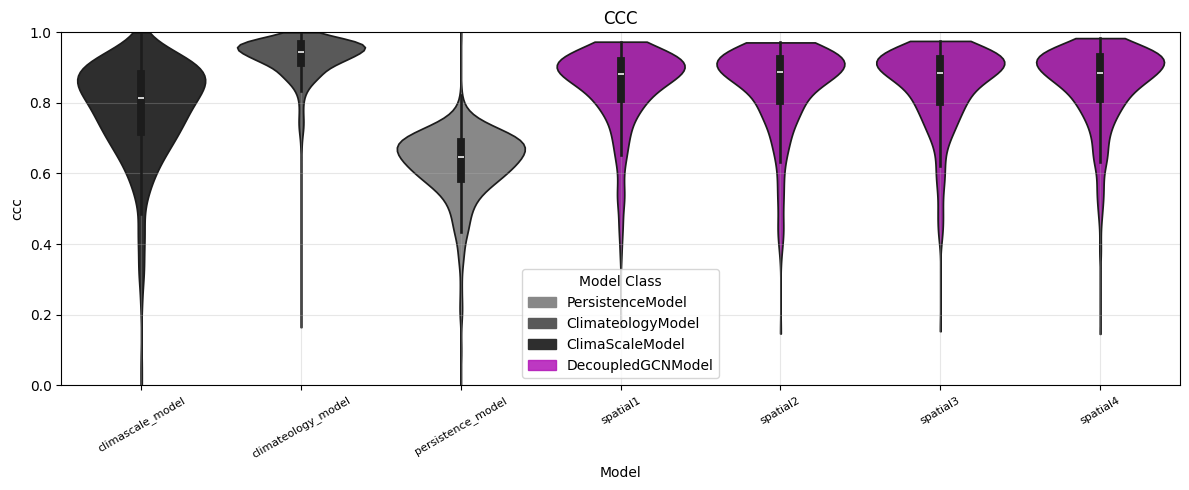

In [29]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'violin', vmin = 0, log=False).show()

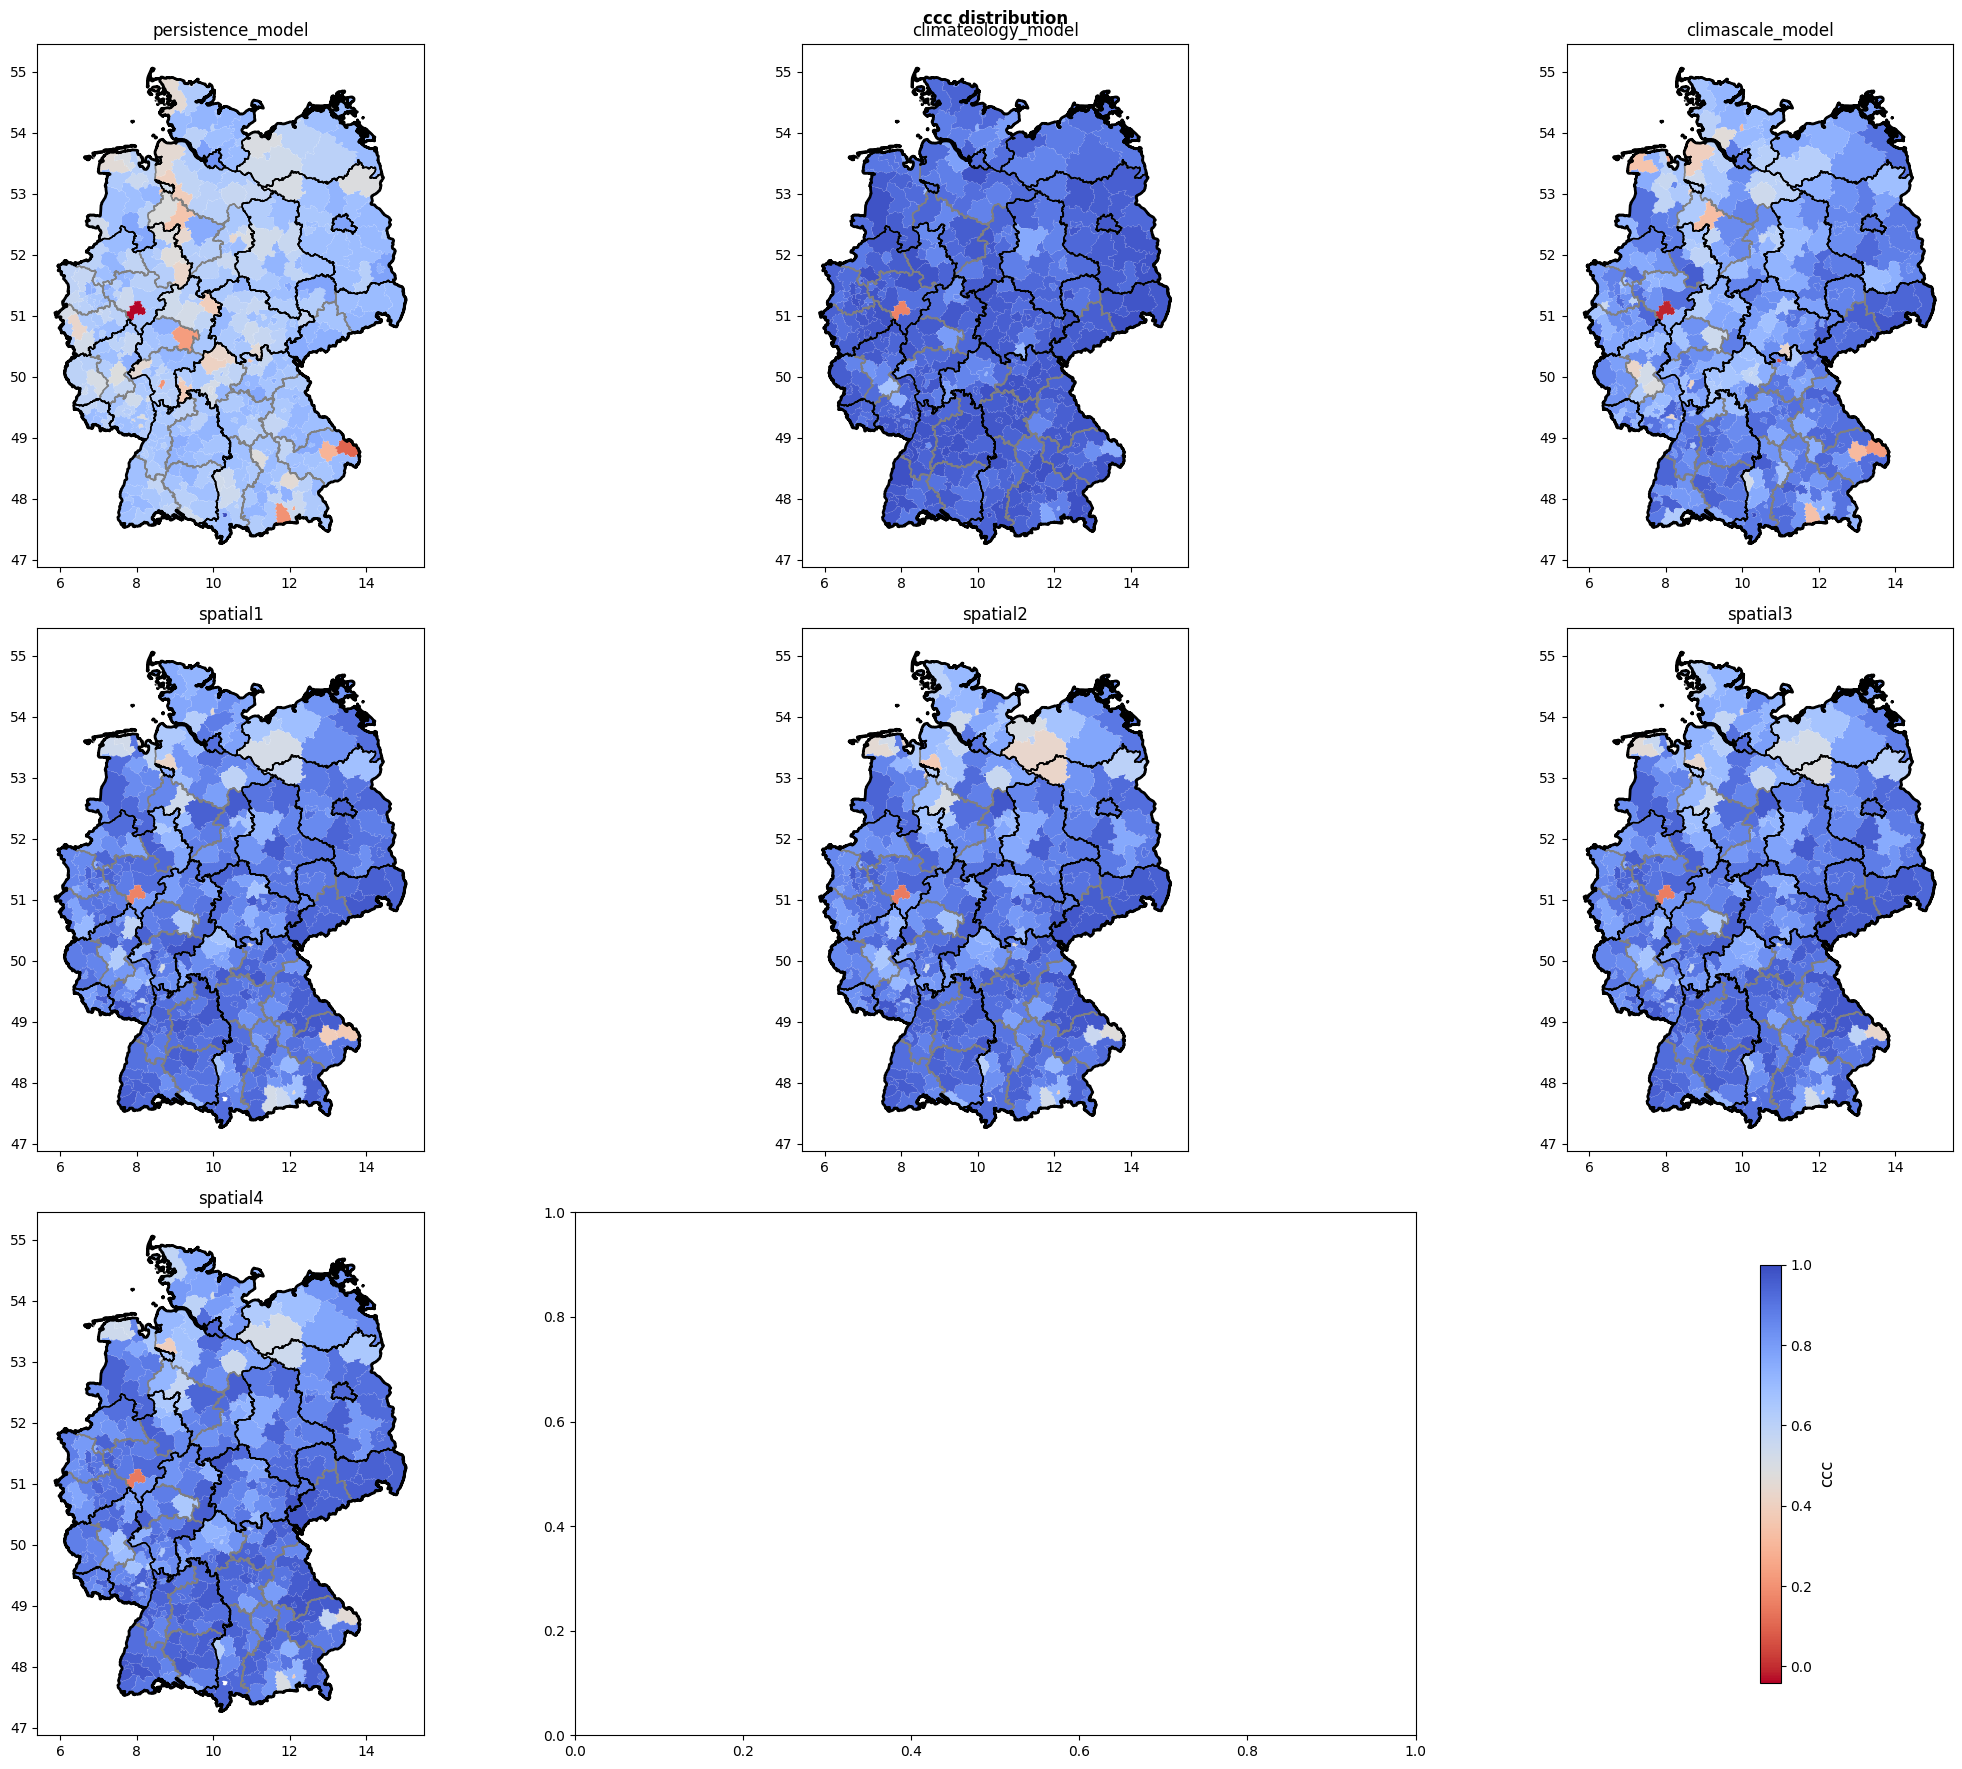

In [30]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'map', vmin = 0, log=False, reverse_scale=True)

In [31]:
metrics = ['ccc']


metrics_df = model_evaluation.data_compilation.get_data(0,'test')['metrics']

model_cols = list(metrics_df['model'].unique())

for metric in metrics:
    df_long = metrics_df[['nuts_node','model',metric]]
    df_wide = df_long.pivot_table(index = 'nuts_node', columns = 'model', values = metric).reset_index(drop = False).reset_index(drop = True)
    df_wide['best'] = df_wide[model_cols].idxmax(axis=1)

In [32]:
# How much better is the best model than second best?
df_wide['best_score']   = df_wide[model_cols].max(axis=1)
df_wide['second_score'] = df_wide[model_cols].apply(
    lambda row: row.nlargest(2).iloc[1], axis=1
)
df_wide['margin'] = df_wide['best_score'] - df_wide['second_score']

# What fraction of nodes have a meaningful margin?
print(df_wide['margin'].describe())
print(f"Nodes with margin > 0.02: {(df_wide['margin'] > 0.02).mean():.1%}")
print(f"Nodes with margin > 0.05: {(df_wide['margin'] > 0.05).mean():.1%}")

# Replot best model only where margin exceeds threshold
threshold = 0.02
df_wide['best_significant'] = df_wide.apply(
    lambda row: row['best'] if row['margin'] > threshold else 'unclear', axis=1
)

count    400.000000
mean       0.060047
std        0.062058
min        0.000000
25%        0.015349
50%        0.042133
75%        0.080771
max        0.357511
Name: margin, dtype: float64
Nodes with margin > 0.02: 69.8%
Nodes with margin > 0.05: 43.0%


In [33]:
# Who wins among the decisive nodes?
decisive = df_wide[df_wide['margin'] > 0.05]
print(decisive['best'].value_counts())
print(decisive['best'].value_counts(normalize=True).round(3))

best
climateology_model    172
Name: count, dtype: int64
best
climateology_model    1.0
Name: proportion, dtype: float64


<Axes: >

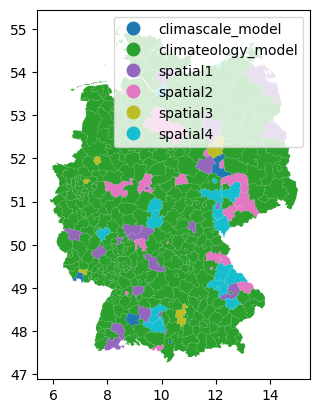

In [34]:
import seaborn as sns 

import pandas as pd
shp = epidata_orchestrator._data_context.shapedata_node

shp = pd.merge(shp, df_wide, on = 'nuts_node')

shp.plot(column = 'best', legend = True)

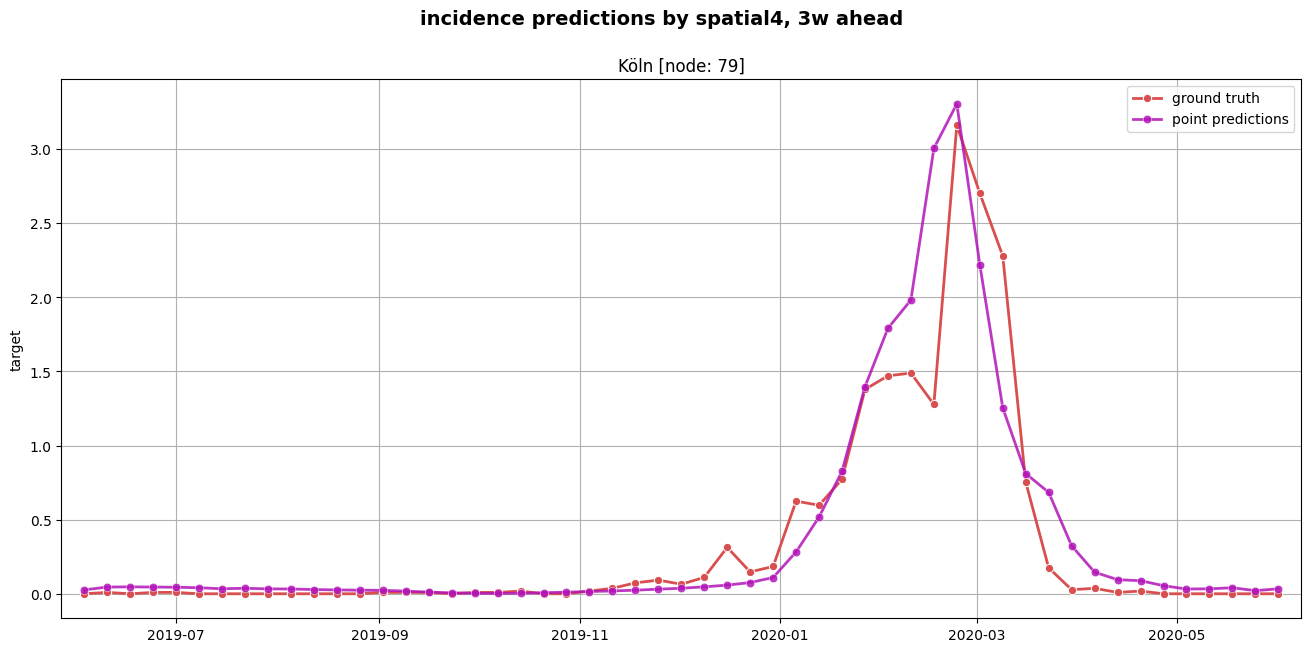

In [20]:

model4.show_forecasts(79).show()

In [21]:
difficult_nodes = [  3,   6,  31,  38,  44,  48,  50,  60, 112, 116, 134, 224, 236, 248, 249, 269, 338, 347, 349]

In [22]:
import seaborn as sns
metrics = model_evaluation.data_compilation.get_data(0,'test')['metrics']
metrics_sel = metrics[['nuts_node','model','ccc']]
metrics_sel = metrics_sel.pivot_table(columns = 'model', values = 'ccc', index = 'nuts_node').reset_index(drop = False)

In [23]:
model_sel = metrics_sel[['nuts_node','spatial1','spatial2','spatial3']]
print(model_sel[(model_sel[['spatial1','spatial2','spatial3']] < 0.6).any(axis=1)]['nuts_node'].index)

KeyError: "['spatial2', 'spatial3'] not in index"

(-0.7502293674309588, 0.4165605514437629)

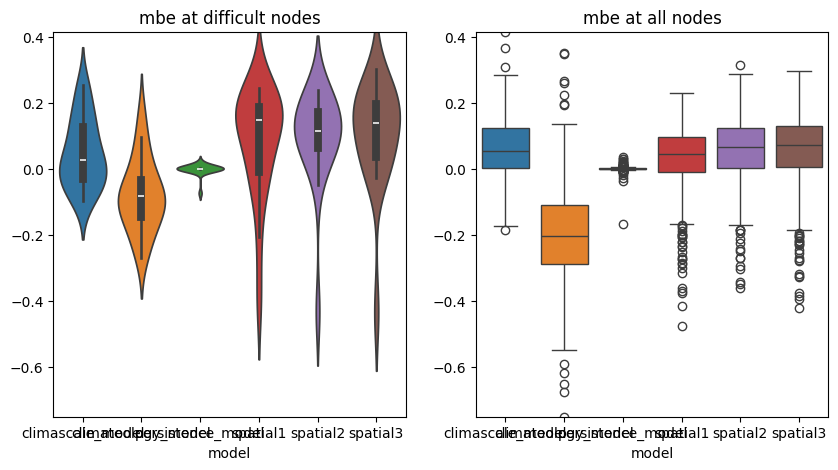

In [ ]:
import matplotlib.pyplot as plt

metric = 'mbe'
metrics = model_evaluation.data_compilation.get_data(0,'test')['metrics']
metrics_sel = metrics[['nuts_node','model',metric]]
metrics_sel = metrics_sel.pivot_table(columns = 'model', values = metric, index = 'nuts_node').reset_index(drop = False)
metrics_sel1= metrics_sel[metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel1 = metrics_sel1.set_index('nuts_node')

lim1, lim2 = metrics[metric].min(), metrics[metric].max()

# control:
metrics_sel2= metrics_sel[~metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel2 = metrics_sel2.set_index('nuts_node')

fig, axes = plt.subplots(1,2, figsize = (10,5))

sns.violinplot(metrics_sel1, ax = axes[0])
sns.boxplot(metrics_sel2,ax = axes[1])

axes[0].set_title(f'{metric} at difficult nodes')
axes[1].set_title(f'{metric} at all nodes')

axes[0].set_ylim(lim1,lim2)
axes[1].set_ylim(lim1,lim2)

<Axes: xlabel='model'>

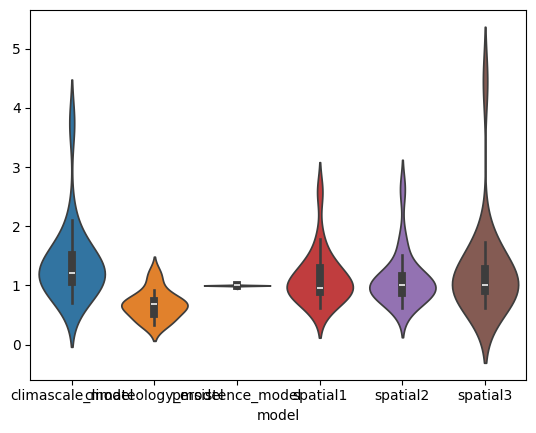

In [ ]:

metrics_sel['gap_idenity']    = metrics_sel['persistence_model'] - metrics_sel['spatial1']
metrics_sel['gap_geononself'] = metrics_sel['persistence_model'] - metrics_sel['spatial2']
metrics_sel['gap_geoself']    = metrics_sel['persistence_model'] - metrics_sel['spatial3']
metrics_sel['gap_ig']         = metrics_sel['spatial1'] - metrics_sel['spatial2']

<Axes: >

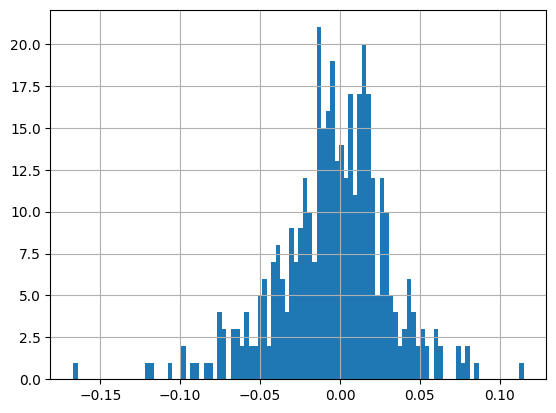

In [ ]:
metrics_sel